In [175]:
import pandas as pd
import sys
from pathlib import Path

root_path = Path().resolve().parent
sys.path.append(str(root_path))

from src.data.load_data import load_all_data
from src.data.preprocess import preprocess_all_data
from src.data.merge_data import build_base_table
from src.data.transform import build_order_level_dataset
from src.features.build_features import build_features

data = load_all_data()
data = preprocess_all_data(data)
df_base = build_base_table(data)
df_model = build_order_level_dataset(df_base)
df_model = build_features(df_model)

df_model.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,price,freight_value,...,days_to_carrier,days_to_deliver,delivery_delay_days,purchase_year,purchase_month,purchase_day,purchase_hour,purchase_weekday,is_weekend_purchase,is_delivered
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,58.90,13.29,...,6.0,7.0,-9.0,2017,9,13,8,2,0,1
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,239.90,19.93,...,8.0,16.0,-3.0,2017,4,26,10,2,0,1
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,199.00,17.87,...,1.0,7.0,-14.0,2018,1,14,14,6,1,1
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,12.99,12.79,...,2.0,6.0,-6.0,2018,8,8,10,2,0,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,199.90,18.14,...,11.0,25.0,-16.0,2017,2,4,13,5,1,1


In [176]:
df_model.shape

(99441, 31)

In [177]:
df_model.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   order_id                        99441 non-null  object        
 1   customer_id                     99441 non-null  object        
 2   order_status                    99441 non-null  object        
 3   order_purchase_timestamp        99441 non-null  datetime64[ns]
 4   order_approved_at               99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date    97658 non-null  datetime64[ns]
 6   order_delivered_customer_date   96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date   99441 non-null  datetime64[ns]
 8   price                           99441 non-null  float64       
 9   freight_value                   99441 non-null  float64       
 10  payment_value                   99440 non-null  float64       
 11  nu

In [178]:
df_model.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,price,freight_value,payment_value,num_items,review_score,...,days_to_carrier,days_to_deliver,delivery_delay_days,purchase_year,purchase_month,purchase_day,purchase_hour,purchase_weekday,is_weekend_purchase,is_delivered
count,99441,99281,97658,96476,99441,99441.000000,99441.000000,99440.000000,98666.000000,98673.000000,...,97658.000000,96476.000000,96476.000000,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000
mean,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800384,2018-01-04 21:49:48.138278400,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232,143.539382,23.833546,159.473791,1.141731,4.086853,...,2.743114,12.094086,-11.876881,2017.539838,6.032220,15.505948,14.770829,2.755735,0.229754,0.970203
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,0.000000,0.000000,0.000000,1.000000,1.000000,...,-172.000000,0.000000,-147.000000,2016.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00,45.950000,13.920000,61.070000,1.000000,4.000000,...,1.000000,6.000000,-17.000000,2017.000000,3.000000,8.000000,11.000000,1.000000,0.000000,1.000000
50%,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00,89.000000,17.510000,104.120000,1.000000,5.000000,...,2.000000,10.000000,-12.000000,2018.000000,6.000000,15.000000,15.000000,3.000000,0.000000,1.000000
75%,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00,153.800000,25.580000,175.792500,1.000000,5.000000,...,4.000000,15.000000,-7.000000,2018.000000,8.000000,23.000000,19.000000,4.000000,0.000000,1.000000
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,13440.000000,1897.760000,13664.080000,21.000000,5.000000,...,125.000000,209.000000,188.000000,2018.000000,12.000000,31.000000,23.000000,6.000000,1.000000,1.000000
std,NaN,NaN,NaN,NaN,NaN,241.433332,26.487925,220.369654,0.538452,1.347287,...,3.625481,9.551746,10.183854,0.505007,3.232999,8.667298,5.326800,1.966495,0.420677,0.170027


In [179]:
df_model.isna().mean().sort_values(ascending=False).head(15)

order_delivered_customer_date     0.029817
delivery_delay_days               0.029817
days_to_deliver                   0.029817
avg_product_name_length           0.021762
avg_product_description_length    0.021762
avg_product_photos_qty            0.021762
order_delivered_carrier_date      0.017930
days_to_carrier                   0.017930
avg_product_height_cm             0.007954
avg_product_width_cm              0.007954
avg_product_weight_g              0.007954
avg_product_length_cm             0.007954
num_items                         0.007794
review_score                      0.007723
order_approved_at                 0.001609
dtype: float64

In [180]:
df_model.groupby('order_status')['review_score'].count()

order_status
approved           2
canceled         605
created            3
delivered      95832
invoiced         309
processing       295
shipped         1032
unavailable      595
Name: review_score, dtype: int64

In [181]:
df_model.groupby('order_status')['review_score'].mean()

order_status
approved       2.500000
canceled       1.803306
created        2.333333
delivered      4.156294
invoiced       1.627832
processing     1.277966
shipped        2.000000
unavailable    1.527731
Name: review_score, dtype: float64

In [182]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   order_id                        99441 non-null  object        
 1   customer_id                     99441 non-null  object        
 2   order_status                    99441 non-null  object        
 3   order_purchase_timestamp        99441 non-null  datetime64[ns]
 4   order_approved_at               99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date    97658 non-null  datetime64[ns]
 6   order_delivered_customer_date   96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date   99441 non-null  datetime64[ns]
 8   price                           99441 non-null  float64       
 9   freight_value                   99441 non-null  float64       
 10  payment_value                   99440 non-null  float64       
 11  nu

In [183]:
df_model[df_model['order_status'] == 'delivered']['review_score'].isnull().sum()

np.int64(646)

In [184]:
df_model['review_score'].isnull().sum()

np.int64(768)

In [185]:
df_model[df_model['order_status'] == 'delivered']['review_score'].isnull().sum()/df_model['review_score'].isnull().sum()


np.float64(0.8411458333333334)

In [186]:
df_model[df_model['order_status'] != 'delivered']['review_score'].isnull().sum()

np.int64(122)

In [187]:
df_model.groupby('order_status')['review_score'].agg(
    total_filas='size',
    no_nulos='count',
    nulos=lambda x: x.isnull().sum(),
    porcentaje = lambda x: x.isnull().sum() / x.sum() *100
)

,total_filas,no_nulos,nulos,porcentaje
order_status,,,,
approved,2,2,0,0.000000
canceled,625,605,20,1.833181
created,5,3,2,28.571429
delivered,96478,95832,646,0.162187
invoiced,314,309,5,0.994036
processing,301,295,6,1.591512
shipped,1107,1032,75,3.633721
unavailable,609,595,14,1.540154


In [188]:
df_model['review_score'].isnull().sum()

np.int64(768)

In [189]:
df_model.isnull().sum().sort_values(ascending=False)

order_delivered_customer_date     2965
delivery_delay_days               2965
days_to_deliver                   2965
avg_product_name_length           2164
avg_product_description_length    2164
avg_product_photos_qty            2164
order_delivered_carrier_date      1783
days_to_carrier                   1783
avg_product_height_cm              791
avg_product_width_cm               791
avg_product_weight_g               791
avg_product_length_cm              791
num_items                          775
review_score                       768
order_approved_at                  160
days_to_approve                    160
payment_value                        1
freight_value                        0
order_estimated_delivery_date        0
order_status                         0
customer_id                          0
order_id                             0
order_purchase_timestamp             0
price                                0
purchase_year                        0
purchase_month           

In [190]:
df_filtered = df_model[df_model['order_status'] == 'delivered']
df_filtered = df_filtered[df_filtered['review_score'].notnull()]
df_filtered.isnull().sum().sort_values()

order_id                             0
customer_id                          0
order_status                         0
order_purchase_timestamp             0
order_estimated_delivery_date        0
num_items                            0
freight_value                        0
price                                0
review_score                         0
purchase_year                        0
purchase_day                         0
purchase_month                       0
purchase_weekday                     0
is_weekend_purchase                  0
is_delivered                         0
purchase_hour                        0
payment_value                        1
order_delivered_carrier_date         2
days_to_carrier                      2
days_to_deliver                      8
order_delivered_customer_date        8
delivery_delay_days                  8
days_to_approve                     14
order_approved_at                   14
avg_product_height_cm               16
avg_product_length_cm    

In [191]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95832 entries, 0 to 99440
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   order_id                        95832 non-null  object        
 1   customer_id                     95832 non-null  object        
 2   order_status                    95832 non-null  object        
 3   order_purchase_timestamp        95832 non-null  datetime64[ns]
 4   order_approved_at               95818 non-null  datetime64[ns]
 5   order_delivered_carrier_date    95830 non-null  datetime64[ns]
 6   order_delivered_customer_date   95824 non-null  datetime64[ns]
 7   order_estimated_delivery_date   95832 non-null  datetime64[ns]
 8   price                           95832 non-null  float64       
 9   freight_value                   95832 non-null  float64       
 10  payment_value                   95831 non-null  float64       
 11  num_ite

In [192]:
df_num = df_filtered.select_dtypes(include=['number'])

In [193]:
df_num.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95832 entries, 0 to 99440
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   price                           95832 non-null  float64
 1   freight_value                   95832 non-null  float64
 2   payment_value                   95831 non-null  float64
 3   num_items                       95832 non-null  float64
 4   review_score                    95832 non-null  float64
 5   avg_product_weight_g            95816 non-null  float64
 6   avg_product_length_cm           95816 non-null  float64
 7   avg_product_height_cm           95816 non-null  float64
 8   avg_product_width_cm            95816 non-null  float64
 9   avg_product_photos_qty          94508 non-null  float64
 10  avg_product_name_length         94508 non-null  float64
 11  avg_product_description_length  94508 non-null  float64
 12  days_to_approve                 95818

In [194]:
df_filtered['order_id'].nunique(),df_filtered.shape[0]

(95832, 95832)

In [195]:
df_filtered.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'price', 'freight_value', 'payment_value', 'num_items', 'review_score',
       'avg_product_weight_g', 'avg_product_length_cm',
       'avg_product_height_cm', 'avg_product_width_cm',
       'avg_product_photos_qty', 'avg_product_name_length',
       'avg_product_description_length', 'days_to_approve', 'days_to_carrier',
       'days_to_deliver', 'delivery_delay_days', 'purchase_year',
       'purchase_month', 'purchase_day', 'purchase_hour', 'purchase_weekday',
       'is_weekend_purchase', 'is_delivered'],
      dtype='object')

In [196]:
df_filtered['order_id'].duplicated().sum()

np.int64(0)

In [197]:
df_filtered.shape

(95832, 31)

In [198]:
df_filtered['order_id'].nunique()

95832

In [199]:
df_filtered.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,price,freight_value,...,days_to_carrier,days_to_deliver,delivery_delay_days,purchase_year,purchase_month,purchase_day,purchase_hour,purchase_weekday,is_weekend_purchase,is_delivered
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,58.90,13.29,...,6.0,7.0,-9.0,2017,9,13,8,2,0,1
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,239.90,19.93,...,8.0,16.0,-3.0,2017,4,26,10,2,0,1
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,199.00,17.87,...,1.0,7.0,-14.0,2018,1,14,14,6,1,1
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,12.99,12.79,...,2.0,6.0,-6.0,2018,8,8,10,2,0,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,199.90,18.14,...,11.0,25.0,-16.0,2017,2,4,13,5,1,1


In [200]:
df_filtered.groupby('order_id')['payment_value'].nunique().value_counts()

payment_value
1    95831
0        1
Name: count, dtype: int64

In [201]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95832 entries, 0 to 99440
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   order_id                        95832 non-null  object        
 1   customer_id                     95832 non-null  object        
 2   order_status                    95832 non-null  object        
 3   order_purchase_timestamp        95832 non-null  datetime64[ns]
 4   order_approved_at               95818 non-null  datetime64[ns]
 5   order_delivered_carrier_date    95830 non-null  datetime64[ns]
 6   order_delivered_customer_date   95824 non-null  datetime64[ns]
 7   order_estimated_delivery_date   95832 non-null  datetime64[ns]
 8   price                           95832 non-null  float64       
 9   freight_value                   95832 non-null  float64       
 10  payment_value                   95831 non-null  float64       
 11  num_ite

In [202]:
df_filtered.isnull().sum().sort_values(ascending=False)

avg_product_description_length    1324
avg_product_photos_qty            1324
avg_product_name_length           1324
avg_product_width_cm                16
avg_product_weight_g                16
avg_product_length_cm               16
avg_product_height_cm               16
days_to_approve                     14
order_approved_at                   14
delivery_delay_days                  8
days_to_deliver                      8
order_delivered_customer_date        8
order_delivered_carrier_date         2
days_to_carrier                      2
payment_value                        1
num_items                            0
review_score                         0
price                                0
freight_value                        0
order_estimated_delivery_date        0
customer_id                          0
order_id                             0
order_purchase_timestamp             0
order_status                         0
purchase_year                        0
purchase_month           

In [203]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    df_filtered[col] = pd.to_datetime(df_filtered[col])

In [204]:
df_filtered['days_to_approve'] = (
    df_filtered['order_approved_at'] - df_filtered['order_purchase_timestamp']
).dt.days

df_filtered['days_to_carrier'] = (
    df_filtered['order_delivered_carrier_date'] - df_filtered['order_approved_at']
).dt.days

df_filtered['days_to_deliver'] = (
    df_filtered['order_delivered_customer_date'] - df_filtered['order_purchase_timestamp']
).dt.days

df_filtered['delivery_delay_days'] = (
    df_filtered['order_delivered_customer_date'] - df_filtered['order_estimated_delivery_date']
).dt.days


In [205]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95832 entries, 0 to 99440
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   order_id                        95832 non-null  object        
 1   customer_id                     95832 non-null  object        
 2   order_status                    95832 non-null  object        
 3   order_purchase_timestamp        95832 non-null  datetime64[ns]
 4   order_approved_at               95818 non-null  datetime64[ns]
 5   order_delivered_carrier_date    95830 non-null  datetime64[ns]
 6   order_delivered_customer_date   95824 non-null  datetime64[ns]
 7   order_estimated_delivery_date   95832 non-null  datetime64[ns]
 8   price                           95832 non-null  float64       
 9   freight_value                   95832 non-null  float64       
 10  payment_value                   95831 non-null  float64       
 11  num_ite

In [206]:
df_filtered.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'price', 'freight_value', 'payment_value', 'num_items', 'review_score',
       'avg_product_weight_g', 'avg_product_length_cm',
       'avg_product_height_cm', 'avg_product_width_cm',
       'avg_product_photos_qty', 'avg_product_name_length',
       'avg_product_description_length', 'days_to_approve', 'days_to_carrier',
       'days_to_deliver', 'delivery_delay_days', 'purchase_year',
       'purchase_month', 'purchase_day', 'purchase_hour', 'purchase_weekday',
       'is_weekend_purchase', 'is_delivered'],
      dtype='object')

In [207]:
df_filtered.isnull().sum()

order_id                             0
customer_id                          0
order_status                         0
order_purchase_timestamp             0
order_approved_at                   14
order_delivered_carrier_date         2
order_delivered_customer_date        8
order_estimated_delivery_date        0
price                                0
freight_value                        0
payment_value                        1
num_items                            0
review_score                         0
avg_product_weight_g                16
avg_product_length_cm               16
avg_product_height_cm               16
avg_product_width_cm                16
avg_product_photos_qty            1324
avg_product_name_length           1324
avg_product_description_length    1324
days_to_approve                     14
days_to_carrier                     16
days_to_deliver                      8
delivery_delay_days                  8
purchase_year                        0
purchase_month           

In [208]:
df_eda = df_filtered.copy()

In [209]:
df_eda[['days_to_deliver', 'delivery_delay_days', 'review_score']].describe()

,days_to_deliver,delivery_delay_days,review_score
count,95824.000000,95824.000000,95832.000000
mean,12.052273,-11.913070,4.156294
std,9.466046,10.111737,1.284515
min,0.000000,-147.000000,1.000000
25%,6.000000,-17.000000,4.000000
50%,10.000000,-12.000000,5.000000
75%,15.000000,-7.000000,5.000000
max,208.000000,188.000000,5.000000


In [210]:
df_eda = df_filtered.dropna(
    subset=['days_to_approve', 'days_to_carrier']
).copy()

In [211]:
q_low = df_eda['delivery_delay_days'].quantile(0.01)
q_high = df_eda['delivery_delay_days'].quantile(0.99)

df_clear = df_eda[
    (df_eda['delivery_delay_days'] >= q_low) &
    (df_eda['delivery_delay_days'] <= q_high)
]

In [212]:
df_clear[['days_to_deliver','delivery_delay_days']].describe()

,days_to_deliver,delivery_delay_days
count,94051.000000,94051.000000
mean,11.592827,-12.083295
std,7.827148,8.146204
min,0.000000,-36.000000
25%,6.000000,-17.000000
50%,10.000000,-12.000000
75%,15.000000,-7.000000
max,85.000000,18.000000


In [213]:
df_clear.isnull().sum()

order_id                             0
customer_id                          0
order_status                         0
order_purchase_timestamp             0
order_approved_at                    0
order_delivered_carrier_date         0
order_delivered_customer_date        0
order_estimated_delivery_date        0
price                                0
freight_value                        0
payment_value                        0
num_items                            0
review_score                         0
avg_product_weight_g                16
avg_product_length_cm               16
avg_product_height_cm               16
avg_product_width_cm                16
avg_product_photos_qty            1307
avg_product_name_length           1307
avg_product_description_length    1307
days_to_approve                      0
days_to_carrier                      0
days_to_deliver                      0
delivery_delay_days                  0
purchase_year                        0
purchase_month           

In [214]:
cols_fill_zero = [
    'avg_product_photos_qty',
    'avg_product_name_length',
    'avg_product_description_length'
]

df_clear[cols_fill_zero] = df_clear[cols_fill_zero].fillna(0)
df_modelo = df_clear.dropna()
df_modelo.isnull().sum()

C:\Users\halex\AppData\Local\Temp\ipykernel_14352\2352464772.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clear[cols_fill_zero] = df_clear[cols_fill_zero].fillna(0)


order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                 0
order_delivered_carrier_date      0
order_delivered_customer_date     0
order_estimated_delivery_date     0
price                             0
freight_value                     0
payment_value                     0
num_items                         0
review_score                      0
avg_product_weight_g              0
avg_product_length_cm             0
avg_product_height_cm             0
avg_product_width_cm              0
avg_product_photos_qty            0
avg_product_name_length           0
avg_product_description_length    0
days_to_approve                   0
days_to_carrier                   0
days_to_deliver                   0
delivery_delay_days               0
purchase_year                     0
purchase_month                    0
purchase_day                      0
purchase_hour               

In [215]:
df_modelo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 94035 entries, 0 to 99440
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   order_id                        94035 non-null  object        
 1   customer_id                     94035 non-null  object        
 2   order_status                    94035 non-null  object        
 3   order_purchase_timestamp        94035 non-null  datetime64[ns]
 4   order_approved_at               94035 non-null  datetime64[ns]
 5   order_delivered_carrier_date    94035 non-null  datetime64[ns]
 6   order_delivered_customer_date   94035 non-null  datetime64[ns]
 7   order_estimated_delivery_date   94035 non-null  datetime64[ns]
 8   price                           94035 non-null  float64       
 9   freight_value                   94035 non-null  float64       
 10  payment_value                   94035 non-null  float64       
 11  num_ite

In [216]:
corr = df_modelo.select_dtypes(include=['number']).corr()
corr['review_score'].sort_values()

days_to_deliver                  -0.310005
delivery_delay_days              -0.241362
days_to_carrier                  -0.147208
num_items                        -0.126987
freight_value                    -0.078452
payment_value                    -0.041286
price                            -0.031805
avg_product_weight_g             -0.026782
avg_product_length_cm            -0.017505
avg_product_height_cm            -0.016327
days_to_approve                  -0.015967
avg_product_width_cm             -0.011485
purchase_weekday                 -0.010135
avg_product_name_length          -0.009458
purchase_year                    -0.008693
is_weekend_purchase              -0.002574
purchase_day                      0.003424
purchase_hour                     0.003597
avg_product_description_length    0.013992
avg_product_photos_qty            0.014242
purchase_month                    0.027316
review_score                      1.000000
is_delivered                           NaN
Name: revie

<Axes: xlabel='days_to_deliver', ylabel='review_score'>

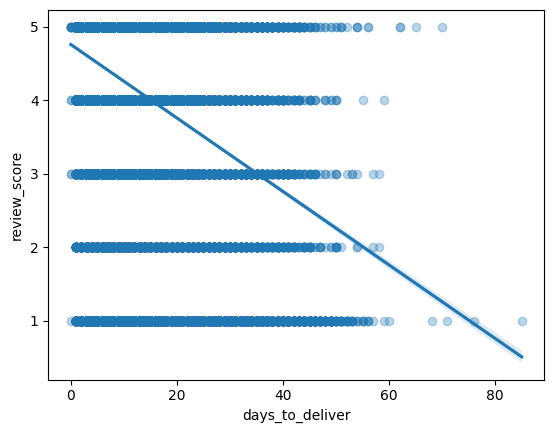

In [217]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(
    data=df_modelo,
    x='days_to_deliver',
    y='review_score',
    scatter_kws={'alpha':0.3}
)

In [218]:
import numpy as np

# crear rangos cada 5 días
bins = np.arange(0, df_modelo['days_to_deliver'].max() + 5, 5)

df_modelo['delivery_bins'] = pd.cut(df_model['days_to_deliver'], bins=bins)

bins_analysis = df_modelo.groupby('delivery_bins')['review_score'].mean().reset_index()

bins_analysis

C:\Users\halex\AppData\Local\Temp\ipykernel_14352\2598936099.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_modelo['delivery_bins'] = pd.cut(df_model['days_to_deliver'], bins=bins)
C:\Users\halex\AppData\Local\Temp\ipykernel_14352\2598936099.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bins_analysis = df_modelo.groupby('delivery_bins')['review_score'].mean().reset_index()


,delivery_bins,review_score
0,"(0.0, 5.0]",4.431154
1,"(5.0, 10.0]",4.349248
2,"(10.0, 15.0]",4.247094
3,"(15.0, 20.0]",4.092917
4,"(20.0, 25.0]",3.751330
5,"(25.0, 30.0]",3.224089
6,"(30.0, 35.0]",2.567116
7,"(35.0, 40.0]",2.133333
8,"(40.0, 45.0]",1.946667
9,"(45.0, 50.0]",1.734940


In [219]:
df_modelo.groupby('delivery_bins')['review_score'].agg(['mean','count'])

C:\Users\halex\AppData\Local\Temp\ipykernel_14352\2364375699.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_modelo.groupby('delivery_bins')['review_score'].agg(['mean','count'])


,mean,count
delivery_bins,,
"(0.0, 5.0]",4.431154,19028
"(5.0, 10.0]",4.349248,32298
"(10.0, 15.0]",4.247094,20818
"(15.0, 20.0]",4.092917,10547
"(20.0, 25.0]",3.751330,5453
"(25.0, 30.0]",3.224089,2798
"(30.0, 35.0]",2.567116,1557
"(35.0, 40.0]",2.133333,840
"(40.0, 45.0]",1.946667,450


In [220]:
bins_analysis = df_modelo.groupby('delivery_bins')['review_score'].agg(['mean','count']).reset_index()

bins_analysis = bins_analysis[bins_analysis['count'] > 50]

C:\Users\halex\AppData\Local\Temp\ipykernel_14352\1598098513.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bins_analysis = df_modelo.groupby('delivery_bins')['review_score'].agg(['mean','count']).reset_index()


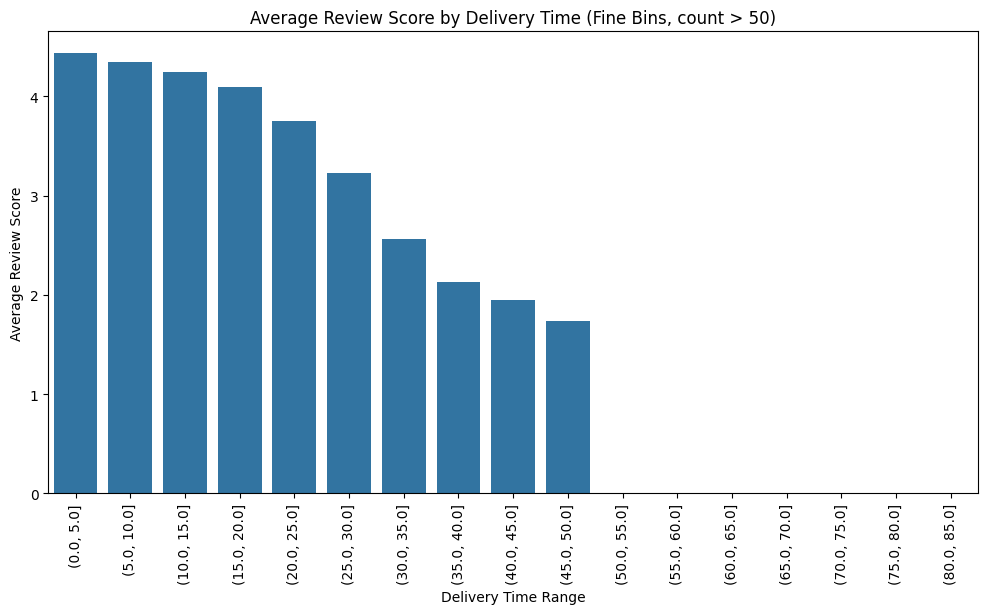

In [221]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=bins_analysis,
    x='delivery_bins',
    y='mean'
)

plt.xticks(rotation=90)
plt.title('Average Review Score by Delivery Time (Fine Bins, count > 50)')
plt.xlabel('Delivery Time Range')
plt.ylabel('Average Review Score')

plt.show()

In [222]:
bins_analysis.sort_values('delivery_bins')

,delivery_bins,mean,count
0,"(0.0, 5.0]",4.431154,19028
1,"(5.0, 10.0]",4.349248,32298
2,"(10.0, 15.0]",4.247094,20818
3,"(15.0, 20.0]",4.092917,10547
4,"(20.0, 25.0]",3.751330,5453
5,"(25.0, 30.0]",3.224089,2798
6,"(30.0, 35.0]",2.567116,1557
7,"(35.0, 40.0]",2.133333,840
8,"(40.0, 45.0]",1.946667,450
9,"(45.0, 50.0]",1.734940,166


In [223]:
df_corr = df_model.select_dtypes(include=['number'])

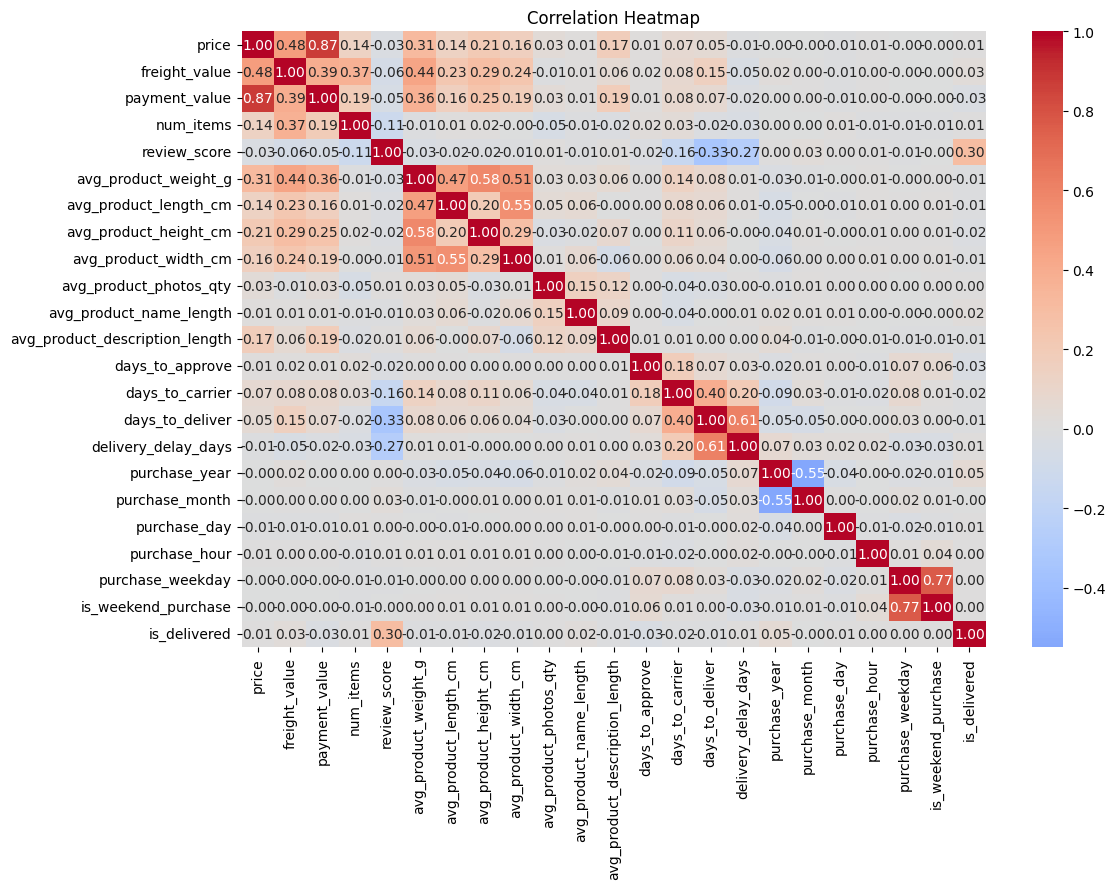

In [224]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    df_corr.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title('Correlation Heatmap')

plt.show()

In [225]:
corr_review = df_corr.corr()['review_score'].sort_values()
corr_review

days_to_deliver                  -0.334047
delivery_delay_days              -0.266998
days_to_carrier                  -0.155831
num_items                        -0.114969
freight_value                    -0.063522
payment_value                    -0.048760
avg_product_weight_g             -0.030581
price                            -0.028518
days_to_approve                  -0.022666
avg_product_height_cm            -0.022159
avg_product_length_cm            -0.019573
avg_product_width_cm             -0.013095
avg_product_name_length          -0.009094
purchase_weekday                 -0.008175
is_weekend_purchase              -0.000903
purchase_day                      0.001656
purchase_year                     0.004764
purchase_hour                     0.005712
avg_product_description_length    0.011127
avg_product_photos_qty            0.014900
purchase_month                    0.027502
is_delivered                      0.299352
review_score                      1.000000
Name: revie

<Axes: xlabel='delivery_delay_days', ylabel='review_score'>

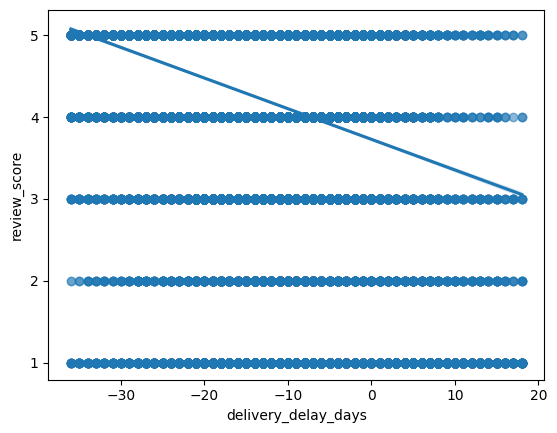

In [226]:
sns.regplot(
    data=df_modelo,
    x='delivery_delay_days',
    y='review_score',
    scatter_kws={'alpha':0.3}
)

<Axes: ylabel='None'>

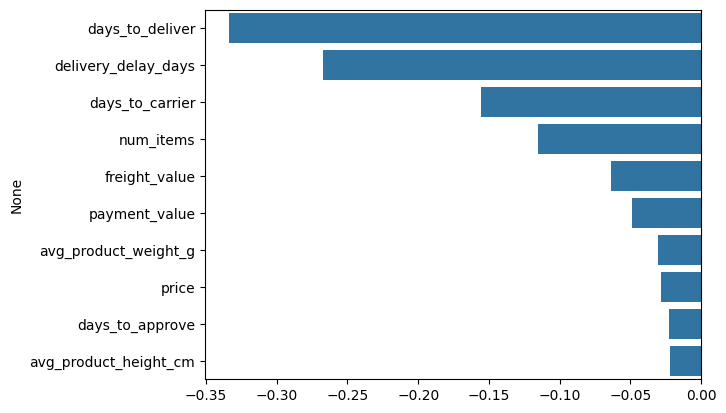

In [227]:
sns.barplot(
    x=corr_review.values[:10],
    y=corr_review.index[:10]
)